# Studio Vente - Marrakech
Cleaning + Training + Evaluation

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../pipeline"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, joblib
from datetime import datetime
from pathlib import Path
from pip_studio import (
    load_data, split_and_encode, build_pipeline, train,
    evaluate, plot_results, predict_price, tune_hyperparams,
    NUMERIC_FEATURES, BINARY_FEATURES, CATEGORICAL_FEATURES, TARGET_LOG
)

RAW_PATH   = Path("../../data/marrakech_immo_vente/studio_vente.csv")
MODEL_PATH = Path("../../model_training/models/xgb_studio_vente.pkl")
META_PATH  = Path("../../model_training/models/xgb_studio_vente_metadata.json")
CLEAN_PATH = Path("../../data/cleaned_data/vente/studio_vente_final.csv")
print("Imports OK")

/home/nouhayla/Desktop/stage/gateone-deploy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 1. Chargement et Cleaning

In [2]:
df = load_data(RAW_PATH)
print(f"Dataset final : {len(df)} studios | {df['zone_clean'].nunique()} zones")

✅ Chargement : 1580 lignes, 34 colonnes
   Maisons : 1528
   EUR→MAD : 32 lignes converties
   Après filtres : 1071 lignes
   Zones : 157 | Top: {'Médina': 164, "M'hamid": 139, "Route d'Ourika": 97, 'Autre': 37, 'Azli': 33}
   Prix médian    : 1,650,000 MAD
   Surface médiane: 120 m²
   pm² médian     : 13,000 MAD/m²
Dataset final : 1071 maisons | 157 zones


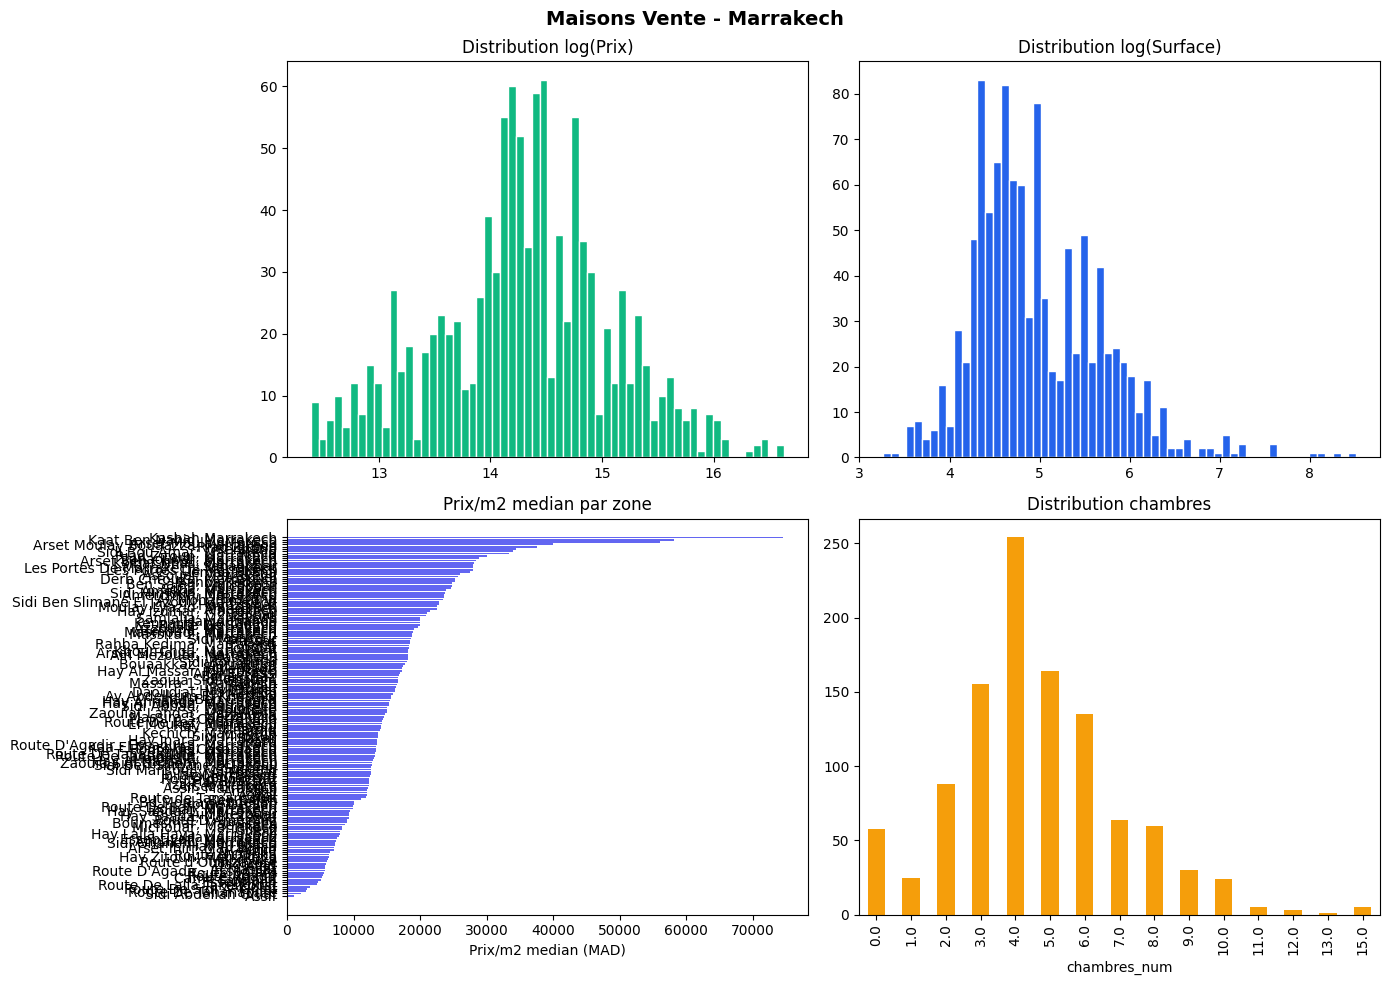

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Studios Vente - Marrakech", fontsize=14, fontweight="bold")

axes[0,0].hist(df["log_prix"], bins=60, color="#10B981", edgecolor="white")
axes[0,0].set_title("Distribution log(Prix)")

axes[0,1].hist(df["log_surface"], bins=60, color="#2563EB", edgecolor="white")
axes[0,1].set_title("Distribution log(Surface)")

med = df.groupby("zone_clean")["prix_m2"].median().sort_values()
axes[1,0].barh(med.index, med.values, color="#6366F1")
axes[1,0].set_xlabel("Prix/m2 median (MAD)")
axes[1,0].set_title("Prix/m2 median par zone")

df["chambres_num"].value_counts().sort_index().plot(kind="bar", ax=axes[1,1], color="#F59E0B")
axes[1,1].set_title("Distribution chambres")
plt.tight_layout(); plt.show()

In [4]:
print("=== Prix median par zone ===")
print(df.groupby("zone_clean")["prix_m2"]
      .agg(["median","count"]).sort_values("median", ascending=False).round(0))

print("\n=== Variance log_prix par zone ===")
print(df.groupby("zone_clean")["log_prix"]
      .agg(["mean","std","count"]).sort_values("std", ascending=False).round(3))

print("\n=== Correlation features -> log_prix ===")
num_check = ["surface_num","log_surface","chambres_num","salles_bain_num",
             "nb_pieces","score_standing","score_confort","piscine",
             "surf_x_piscine","surf_x_ch"]
avail = [c for c in num_check if c in df.columns]
print(df[avail+["log_prix"]].corr()["log_prix"].drop("log_prix")
      .sort_values(ascending=False).round(3))

=== Prix median par zone ===
                                   median  count
zone_clean                                      
Kasbah Marrakech                  74534.0      1
Kaat Ben Nahid, Marrakech         58154.0      1
Arset Moulay Moussa               56000.0      1
Arset Moulay Bouaazza, Marrakech  40000.0      1
Studio Zitoun                       37500.0      1
...                                   ...    ...
Akioud                             3429.0      1
Route De Sidi A. Ghiat             3035.0      6
Route De Tahanaoute                2809.0      9
Sidi Abdellah Ghiat                2083.0      3
Assif                              1108.0      1

[157 rows x 2 columns]

=== Variance log_prix par zone ===
                                 mean    std  count
zone_clean                                         
Es Saada                       14.040  1.425      5
Les Portes De Marrakech        14.636  1.401      4
Arset El Houta                 13.388  1.355      2
Route D'Amez

## 2. Split et Feature Engineering

In [5]:
X_train, X_test, y_train, y_test, df_train, df_test, stats = split_and_encode(
    df, test_size=0.2, random_state=42
)
print(f"Features total : {X_train.shape[1]}")
print(f"  NUMERIC : {len(stats['numeric_cols'])}")
print(f"  CATEG   : {len(stats['categorical_cols'])}")

   Train : 856 | Test : 215
Features total : 49
  NUMERIC : 45
  CATEG   : 4


## 3. Baseline

In [6]:
pipeline_baseline = build_pipeline(stats)
pipeline_baseline = train(pipeline_baseline, X_train, y_train)
metrics_baseline  = evaluate(pipeline_baseline, X_test, y_test, df_test,
                              X_train=X_train, y_train=y_train)

🚀 Entraînement...

═════════════════════════════════════════════
  MÉTRIQUES — MAISON VENTE
═════════════════════════════════════════════
  MAE              :         393,621 MAD
  RMSE             :         743,589 MAD
  R²               :          0.8999
  MAPE             :           19.81 %
  CV R² (5 folds)  : 0.8995 ± 0.0081
═════════════════════════════════════════════
  Erreur <= 10%  : 37.2% des cas
  Erreur <= 15%  : 47.4% des cas
  Erreur <= 20%  : 63.7% des cas
  Erreur <= 30%  : 78.6% des cas
  Erreur <= 50%  : 94.4% des cas


## 4. Tuning Optuna

In [7]:
best_params, study = tune_hyperparams(X_train, y_train, stats, n_trials=150)

🔍 Optuna 150 trials sur X_train (CV 5-fold)...


Best trial: 147. Best value: 0.909668: 100%|██████████| 150/150 [02:01<00:00,  1.24it/s]

✅ Meilleur R² CV : 0.9097
   n_estimators                  : 1480
   max_depth                     : 5
   learning_rate                 : 0.008455882069178706
   max_leaves                    : 60
   subsample                     : 0.6233091609364844
   colsample_bytree              : 0.9733698206316449
   colsample_bylevel             : 0.8867733579288996
   min_child_weight              : 8
   reg_alpha                     : 0.005956191882509819
   reg_lambda                    : 0.06666026513520636
   gamma                         : 0.17334462963711875


In [8]:
pipeline_final = build_pipeline(stats, best_params)
pipeline_final = train(pipeline_final, X_train, y_train)
metrics_final  = evaluate(pipeline_final, X_test, y_test, df_test,
                           X_train=X_train, y_train=y_train)

r2_base = metrics_baseline["R²"]
r2_fin  = metrics_final["R²"]
mape_b  = metrics_baseline["MAPE (%)"]
mape_f  = metrics_final["MAPE (%)"]
print(f"\n=== Gain vs baseline ===")
print(f"  R2   : {r2_base:.4f} -> {r2_fin:.4f}  ({r2_fin - r2_base:+.4f})")
print(f"  MAPE : {mape_b:.2f}% -> {mape_f:.2f}%")

🚀 Entraînement...

═════════════════════════════════════════════
  MÉTRIQUES — MAISON VENTE
═════════════════════════════════════════════
  MAE              :         394,852 MAD
  RMSE             :         739,143 MAD
  R²               :          0.9075
  MAPE             :           19.75 %
  CV R² (5 folds)  : 0.9089 ± 0.0063
═════════════════════════════════════════════
  Erreur <= 10%  : 33.5% des cas
  Erreur <= 15%  : 47.4% des cas
  Erreur <= 20%  : 62.3% des cas
  Erreur <= 30%  : 81.4% des cas
  Erreur <= 50%  : 94.9% des cas

=== Gain vs baseline ===
  R2   : 0.8999 -> 0.9075  (+0.0076)
  MAPE : 19.81% -> 19.75%


## 5. Analyse erreurs

In [9]:
y_pred_log = pipeline_final.predict(X_test)
prix_pred  = np.exp(y_pred_log)
prix_reel  = df_test["prix_num"].values
erreur_pct = np.abs(prix_pred - prix_reel) / prix_reel * 100

df_err = X_test.copy()
df_err["erreur_pct"]  = erreur_pct
df_err["prix_reel"]   = prix_reel
df_err["prix_predit"] = prix_pred
df_err["surface"]     = df_test["surface_num"].values

print("=== MAPE par zone ===")
print(df_err.groupby("zone_clean")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean", ascending=False).round(1))

print("\n=== MAPE par segment_prix ===")
print(df_err.groupby("segment_prix")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean", ascending=False).round(1))

print("\n=== MAPE par cat_surface ===")
print(df_err.groupby("cat_surface")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean", ascending=False).round(1))

print("\n=== Top 10 pires predictions ===")
print(df_err.nlargest(10,"erreur_pct")[
    ["surface","zone_clean","segment_prix","prix_reel","prix_predit","erreur_pct"]
].to_string())

=== MAPE par zone ===
                        mean  count
zone_clean                         
Assif                   99.7      1
Daoudiat, Marrakech     98.8      1
Es Saada                81.7      1
Hay Al Hassani          52.9      1
Kasbah Marrakech        45.3      1
...                      ...    ...
Bouaakkaz                2.2      1
Bouaakkaz, Marrakech     2.2      1
Sidi Mimoun, Marrakech   2.1      1
Assouel                  1.3      1
Sidi Abbad, Marrakech    1.1      1

[79 rows x 2 columns]

=== MAPE par segment_prix ===
              mean  count
segment_prix             
eco           28.2     48
ultra         19.0     17
mid           18.0     93
premium       15.8     57

=== MAPE par cat_surface ===
             mean  count
cat_surface             
estate       27.7      6
tiny         22.1     54
large        19.9     32
medium       19.3     36
xlarge       18.2     27
small        17.7     60

=== Top 10 pires predictions ===
      surface           zone_clean s

## 6. Graphiques

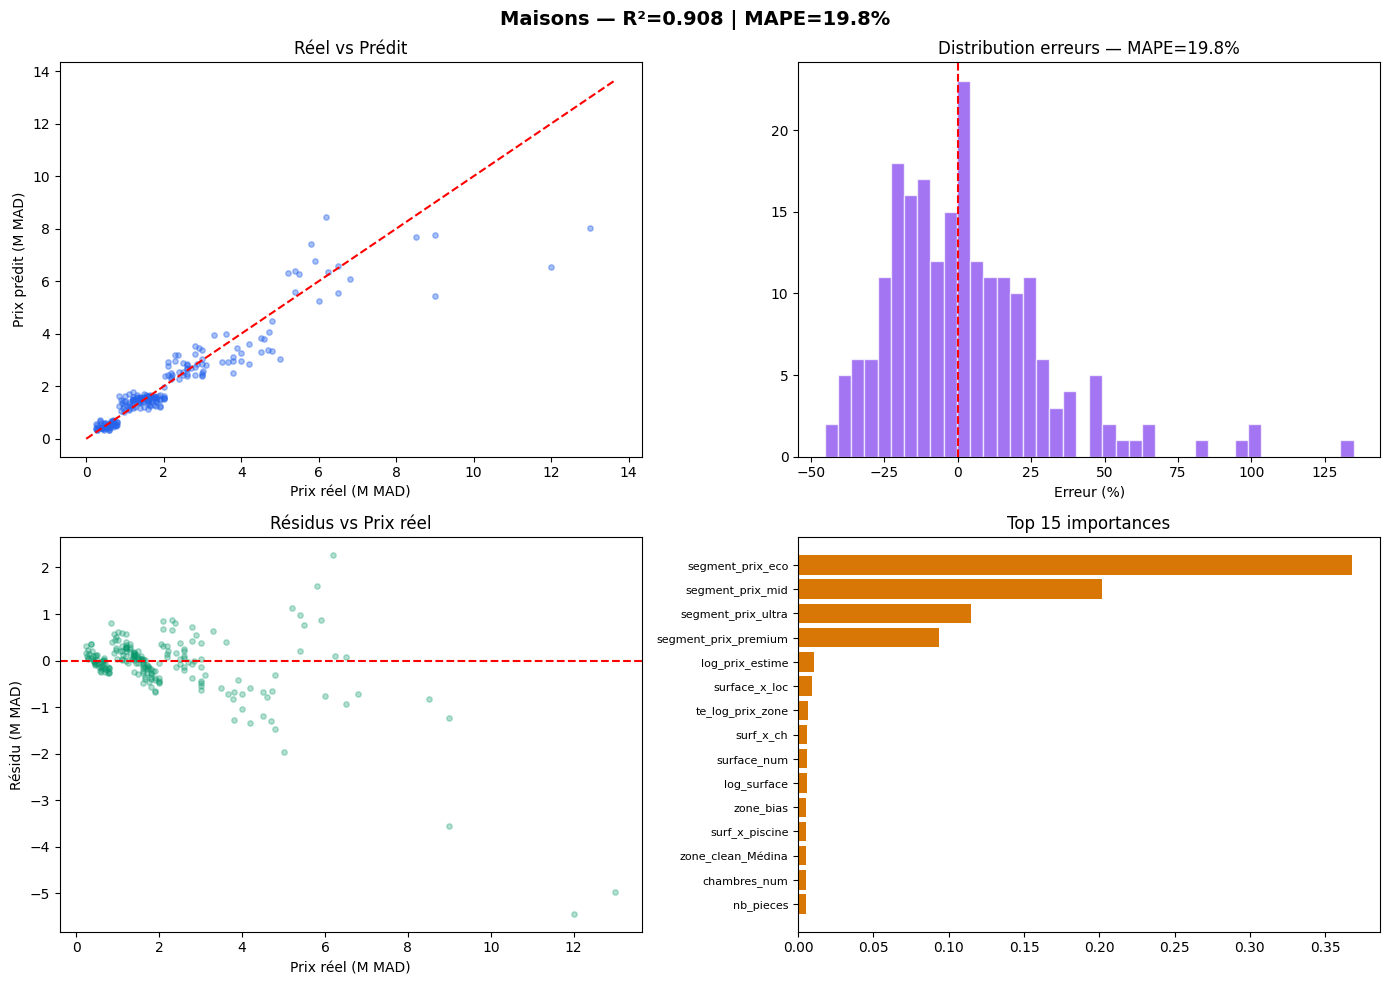

In [10]:
plot_results(pipeline_final, X_test, df_test, metrics_final)

## 7. Sauvegarde

In [11]:
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(CLEAN_PATH), exist_ok=True)

joblib.dump({"pipeline": pipeline_final, "stats": stats}, MODEL_PATH)
print(f"Modele sauvegarde -> {MODEL_PATH}")

r2_val   = round(float(metrics_final["R²"]), 4)
mape_val = round(float(metrics_final["MAPE (%)"]), 2)
mae_val  = round(float(metrics_final["MAE (MAD)"]), 0)
rmse_val = round(float(metrics_final["RMSE (MAD)"]), 0)
r2_base  = round(float(metrics_baseline["R²"]), 4)
mb_mape  = round(float(metrics_baseline["MAPE (%)"]), 2)

metadata = {
    "date"            : datetime.now().strftime("%Y-%m-%d"),
    "version"         : "v1_optuna",
    "modele"          : "XGBRegressor",
    "type_bien"       : "studio_vente",
    "target"          : "log(prix_total)",
    "n_lignes_train"  : len(X_train),
    "n_lignes_test"   : len(X_test),
    "n_features"      : X_train.shape[1],
    "n_zones"         : int(df["zone_clean"].nunique()),
    "metriques_baseline": {"R2": r2_base, "MAPE": mb_mape},
    "metriques_test"  : {"R2": r2_val, "MAE": mae_val, "RMSE": rmse_val, "MAPE": mape_val},
    "cv_r2_optuna"    : round(study.best_value, 4),
    "hyperparametres" : study.best_params,
}
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

df.to_csv(CLEAN_PATH, index=False)

print(f"\n" + "="*50)
print("  RESUME FINAL - STUDIO VENTE")
print("="*50)
print(f"  Donnees  : {len(df):,} studios | {df['zone_clean'].nunique()} zones")
print(f"  R2 final : {r2_val}")
print(f"  MAE      : {mae_val:,.0f} MAD")
print(f"  MAPE     : {mape_val} %")
print(f"  CV R2    : {study.best_value:.4f}")
print("="*50)

Modele sauvegarde -> ../../model_training/models/xgb_maison_vente.pkl

  RESUME FINAL - MAISON VENTE
  Donnees  : 1,071 maisons | 157 zones
  R2 final : 0.9075
  MAE      : 394,852 MAD
  MAPE     : 19.75 %
  CV R2    : 0.9097


## 8. Prediction unitaire

In [12]:
saved           = joblib.load(MODEL_PATH)
pipeline_loaded = saved["pipeline"]
stats_loaded    = saved["stats"]

studio_exemple = {
    "surface_num"      : 150,
    "zone_clean"       : "M'hamid",
    "localisation_fine": "mhamid",
    "chambres_num"     : 4,
    "salles_bain_num"  : 2,
    "piscine"          : 0,
    "parking"          : 1,
    "terrasse"         : 1,
    "jardin"           : 1,
    "climatisation"    : 0,
    "titre"            : "Beau studio moderne M'hamid jardin parking",
}

result   = predict_price(pipeline_loaded, studio_exemple, stats_loaded)
prix_min = result["prix_point"] * 0.75
prix_max = result["prix_point"] * 1.25
print(f"  Fourchette : {prix_min:,.0f} - {prix_max:,.0f} MAD")


💰 Maison — 150 m² | M'hamid
   Prix estimé : 2,865,000 MAD
   Prix/m²     : 19,100 MAD/m²
  Fourchette : 2,148,910 - 3,581,518 MAD
